In [1]:
!nvidia-smi

Mon Aug 12 16:50:15 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.01             Driver Version: 535.183.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       On  | 00000000:00:1E.0 Off |                    0 |
| N/A   27C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/home/jovyan/workspace/solar-flare


In [4]:
!git clone https://github.com/SkalskiP/yolov9.git
%cd yolov9
!pip install -r requirements.txt -q

Cloning into 'yolov9'...
remote: Enumerating objects: 325, done.
remote: Counting objects: 100% (218/218), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 325 (delta 159), reused 156 (delta 156), pack-reused 107
Receiving objects: 100% (325/325), 2.23 MiB | 22.66 MiB/s, done.
Resolving deltas: 100% (165/165), done.
/home/jovyan/workspace/solar-flare/yolov9/yolov9


In [5]:
!pip install -q roboflow

In [6]:
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-e.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-c.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-e.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-m.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-s.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-s2.pt

In [7]:
!ls -la {HOME}/weights

total 470268
drwxr-sr-x  2 jovyan jovyan      4096 Aug 12 16:52 .
drwxr-sr-x 10 jovyan jovyan      4096 Aug 12 16:52 ..
-rw-r--r--  1 jovyan jovyan  51508261 Feb 18 12:36 gelan-c.pt
-rw-r--r--  1 jovyan jovyan 117203713 Feb 18 12:36 gelan-e.pt
-rw-r--r--  1 jovyan jovyan  40711265 Jun  1 12:20 gelan-m.pt
-rw-r--r--  1 jovyan jovyan  13664085 Jun  8 15:37 gelan-s2.pt
-rw-r--r--  1 jovyan jovyan  15075033 Jun  5 11:34 gelan-s.pt
-rw-r--r--  1 jovyan jovyan 103153312 Feb 18 12:36 yolov9-c.pt
-rw-r--r--  1 jovyan jovyan 140217688 Feb 18 12:36 yolov9-e.pt


In [8]:
!wget -P {HOME}/data -q https://media.roboflow.com/notebooks/examples/dog.jpeg

In [9]:
SOURCE_IMAGE_PATH = f"{HOME}/dog.jpeg"

In [19]:
!python detect.py --weights {HOME}/weights/gelan-c.pt --conf 0.1 --source {HOME}/data/dog.jpeg --device 0

detect: weights=['/home/jovyan/workspace/solar-flare/weights/gelan-c.pt'], source=/home/jovyan/workspace/solar-flare/data/dog.jpeg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.1, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 1e33dbb Python-3.10.13 torch-2.1.0 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 467 layers, 25472640 parameters, 0 gradients, 102.8 GFLOPs
image 1/1 /home/jovyan/workspace/solar-flare/data/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 1 handbag, 110.0ms
Speed: 0.5ms pre-process, 110.0ms inference, 510.4ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp2


In [18]:
!ls {HOME}

coco		 docs	    requirements.txt	  solar-flare.ipynb
coco_convert.py  LICENSE    saturn.ipynb	  weights
data		 README.md  sdo_hmii_flat_orange  yolov9


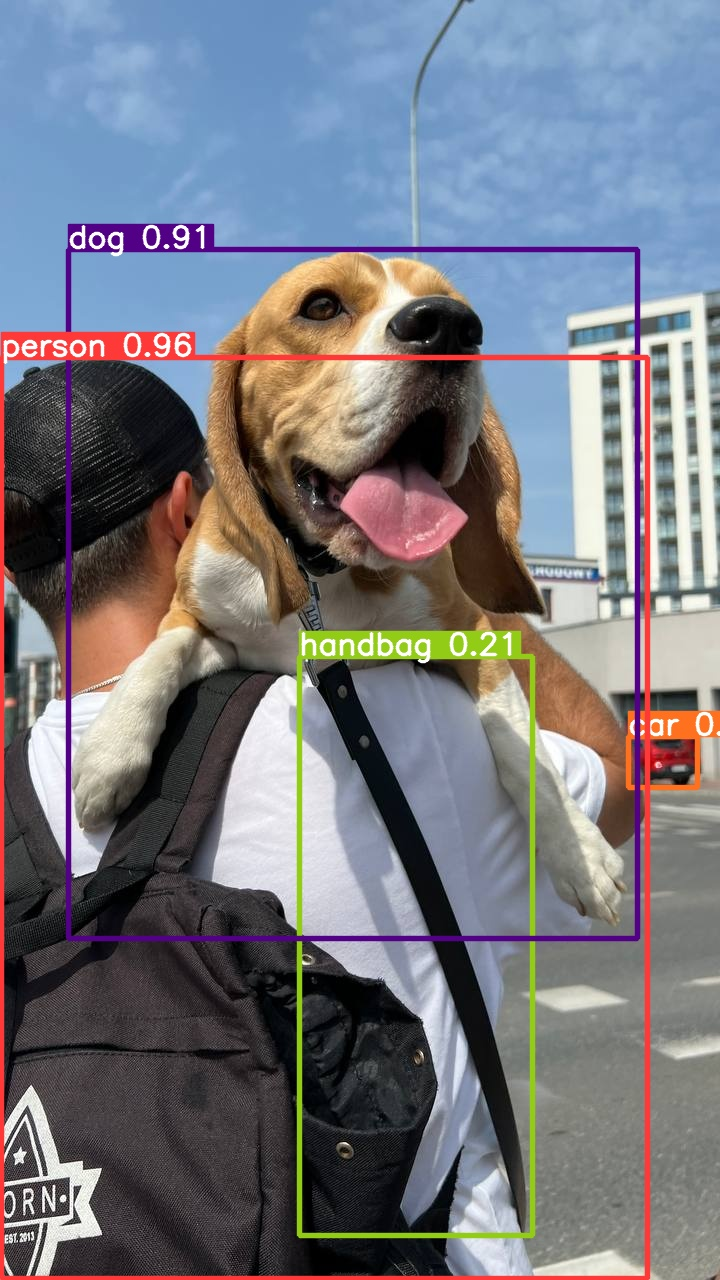

In [21]:
from IPython.display import Image

Image(filename=f"{HOME}/yolov9/yolov9/runs/detect/exp/dog.jpeg", width=600)

In [22]:
!python detect.py --weights {HOME}/weights/yolov9-e.pt --conf 0.1 --source {HOME}/data/dog.jpeg --device 0

detect: weights=['/home/jovyan/workspace/solar-flare/weights/yolov9-e.pt'], source=/home/jovyan/workspace/solar-flare/data/dog.jpeg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.1, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 1e33dbb Python-3.10.13 torch-2.1.0 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 1119 layers, 69470144 parameters, 0 gradients, 244.0 GFLOPs
image 1/1 /home/jovyan/workspace/solar-flare/data/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 1 backpack, 1 handbag, 147.3ms
Speed: 0.4ms pre-process, 147.3ms inference, 478.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp3


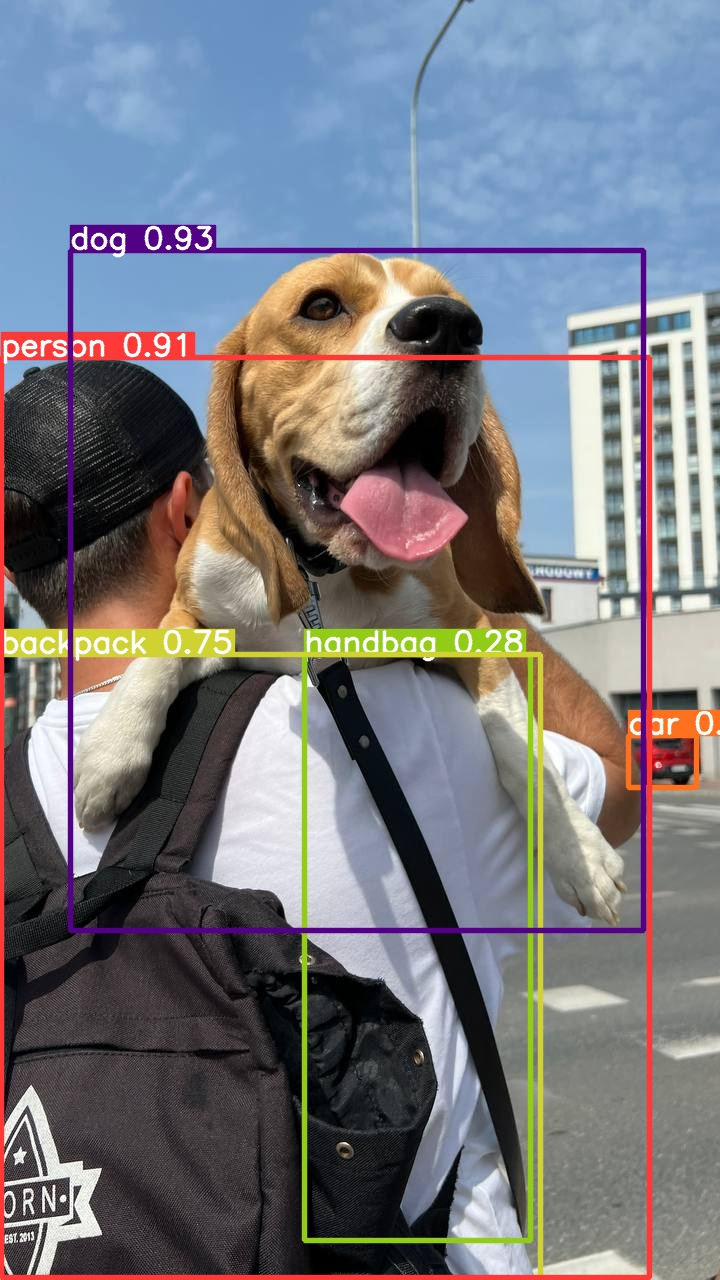

In [23]:
from IPython.display import Image

Image(filename=f"{HOME}/yolov9/yolov9/runs/detect/exp3/dog.jpeg", width=600)

In [24]:
%cd {HOME}/yolov9

/home/jovyan/workspace/solar-flare/yolov9


In [25]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ENV")
project = rf.workspace("solarflarelabelling").project("sunspot-single-v-cluster-detection")
version = project.version(9)
dataset = version.download("yolov9")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to sunspot-single-V-cluster-detection-9 in yolov9:: 100%|██████████| 906/906 [00:00<00:00, 10788.46it/s]


In [26]:
%cd {HOME}/yolov9

!python train.py \
--batch 16 --epochs 25 --img 640 --device 0 --min-items 0 --close-mosaic 15 \
--data {dataset.location}/data.yaml \
--weights {HOME}/weights/gelan-c.pt \
--cfg models/detect/gelan-c.yaml \
--hyp hyp.scratch-high.yaml

/home/jovyan/workspace/solar-flare/yolov9
train: weights=/home/jovyan/workspace/solar-flare/weights/gelan-c.pt, cfg=models/detect/gelan-c.yaml, data=/home/jovyan/workspace/solar-flare/yolov9/sunspot-single-V-cluster-detection-9/data.yaml, hyp=hyp.scratch-high.yaml, epochs=25, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=0, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=exp, exist_ok=False, quad=False, cos_lr=False, flat_cos_lr=False, fixed_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, min_items=0, close_mosaic=15, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
YOLOv5 🚀 1e33dbb Python-3.10.13 torch-2.1.0 CUDA:0 (Tesla T4, 15102MiB)

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, wa

In [28]:
!ls {HOME}/yolov9/runs/train/exp

confusion_matrix.png
events.out.tfevents.1723482051.w-samtr-solar-sunspot-0e54c5bc9e444979a4ac88c687338425-65d7pfw9.805.0
F1_curve.png
hyp.yaml
labels_correlogram.jpg
labels.jpg
opt.yaml
P_curve.png
PR_curve.png
R_curve.png
results.csv
results.png
weights


/home/jovyan/workspace/solar-flare/yolov9/runs/train/exp/results.png


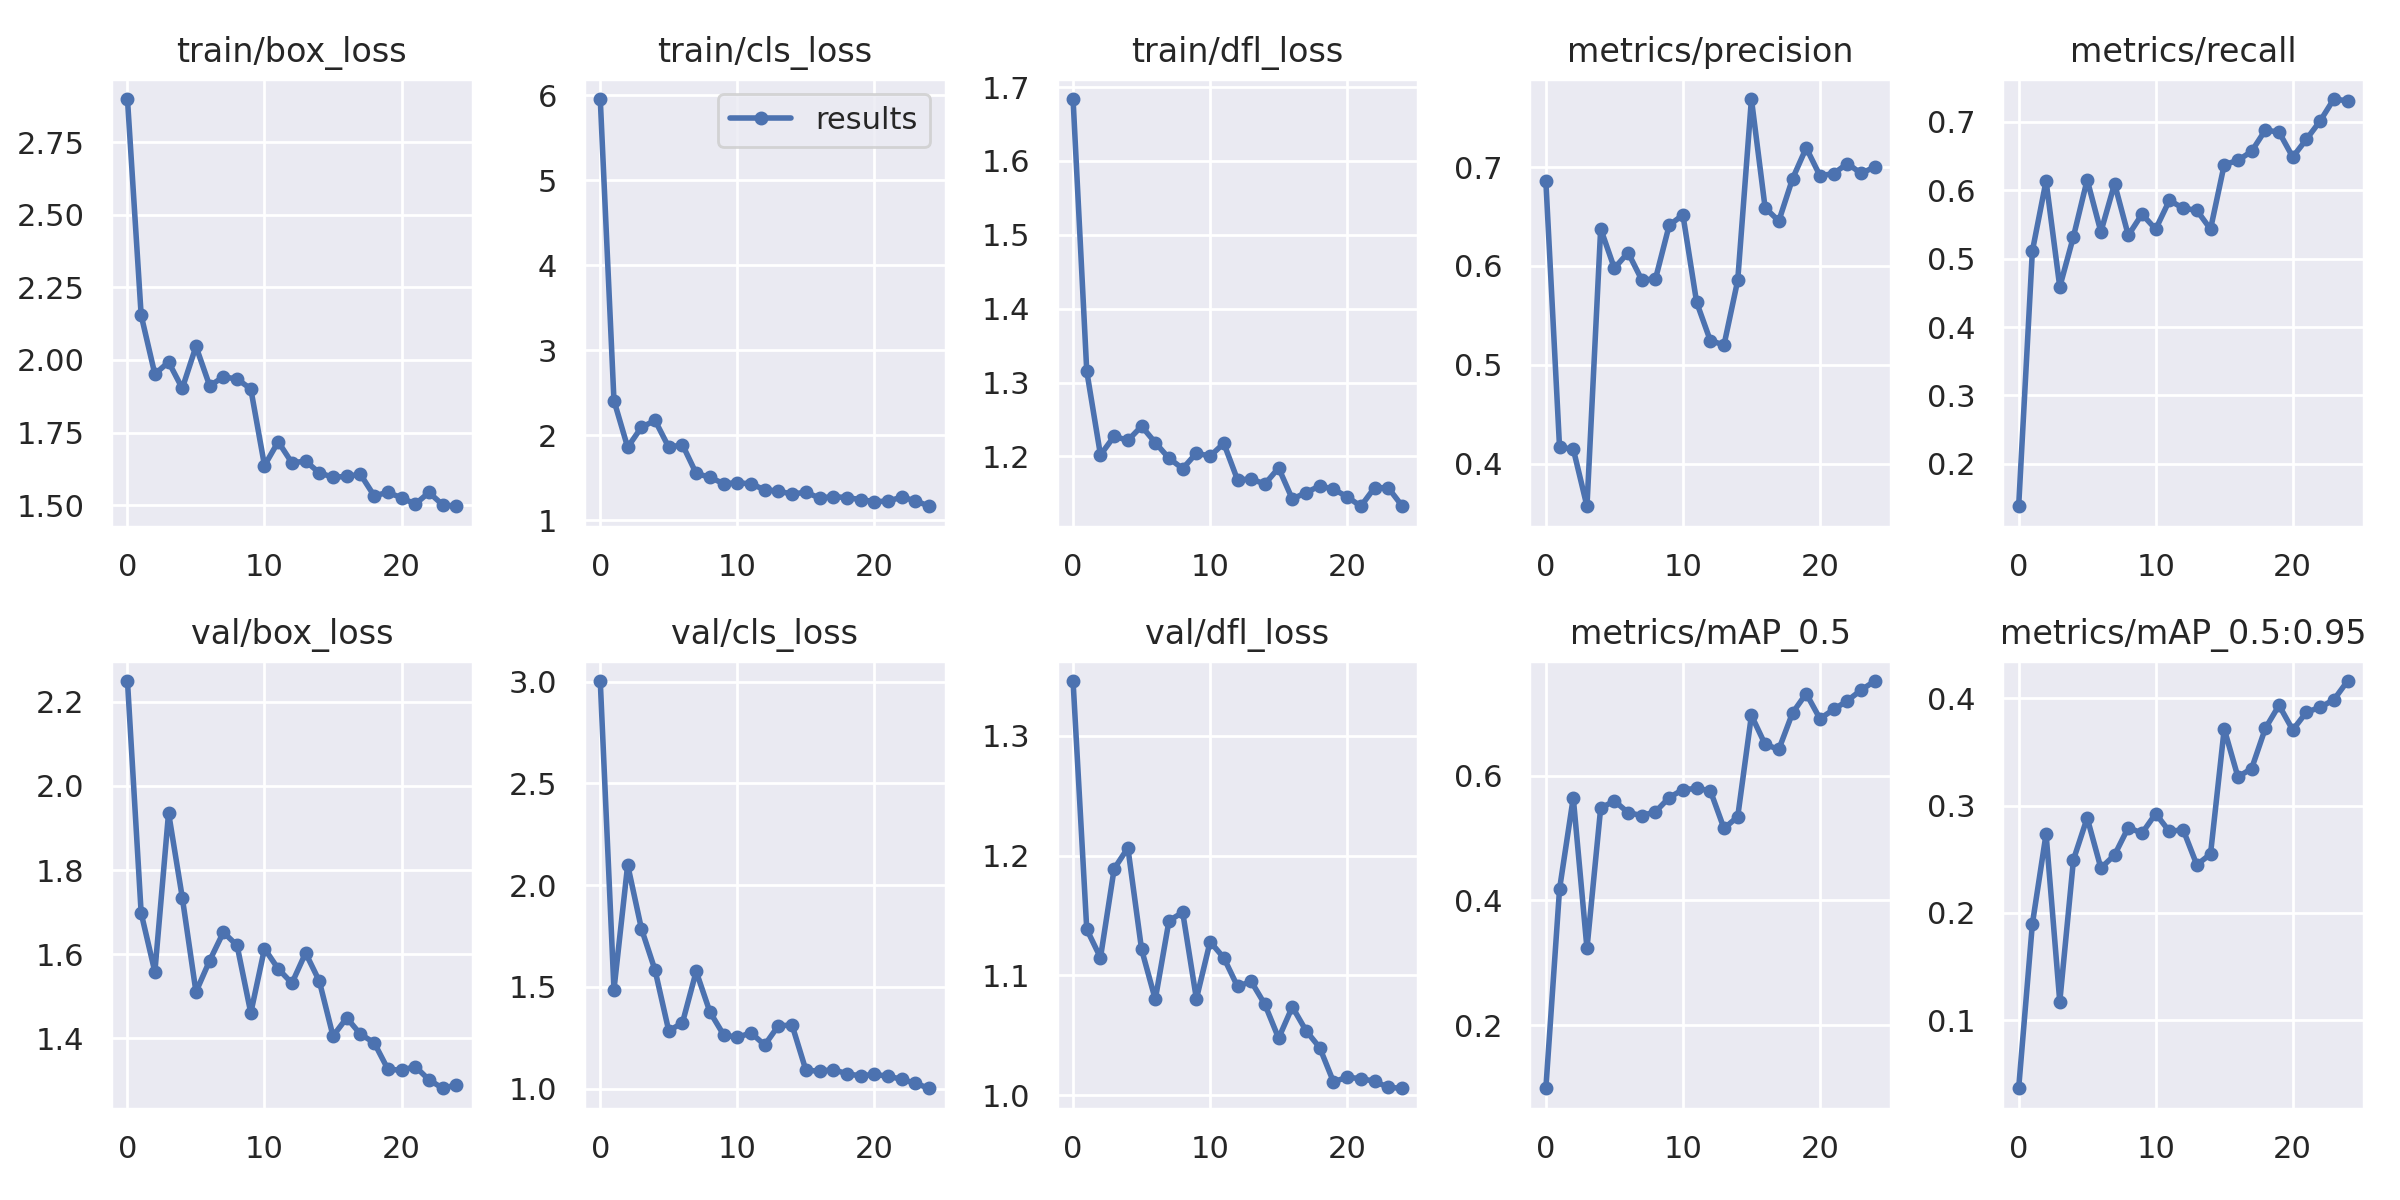

In [33]:
from IPython.display import Image
print(f"{HOME}/yolov9/runs/train/exp/results.png")
Image(filename=f"{HOME}/yolov9/runs/train/exp/results.png", width=1000)

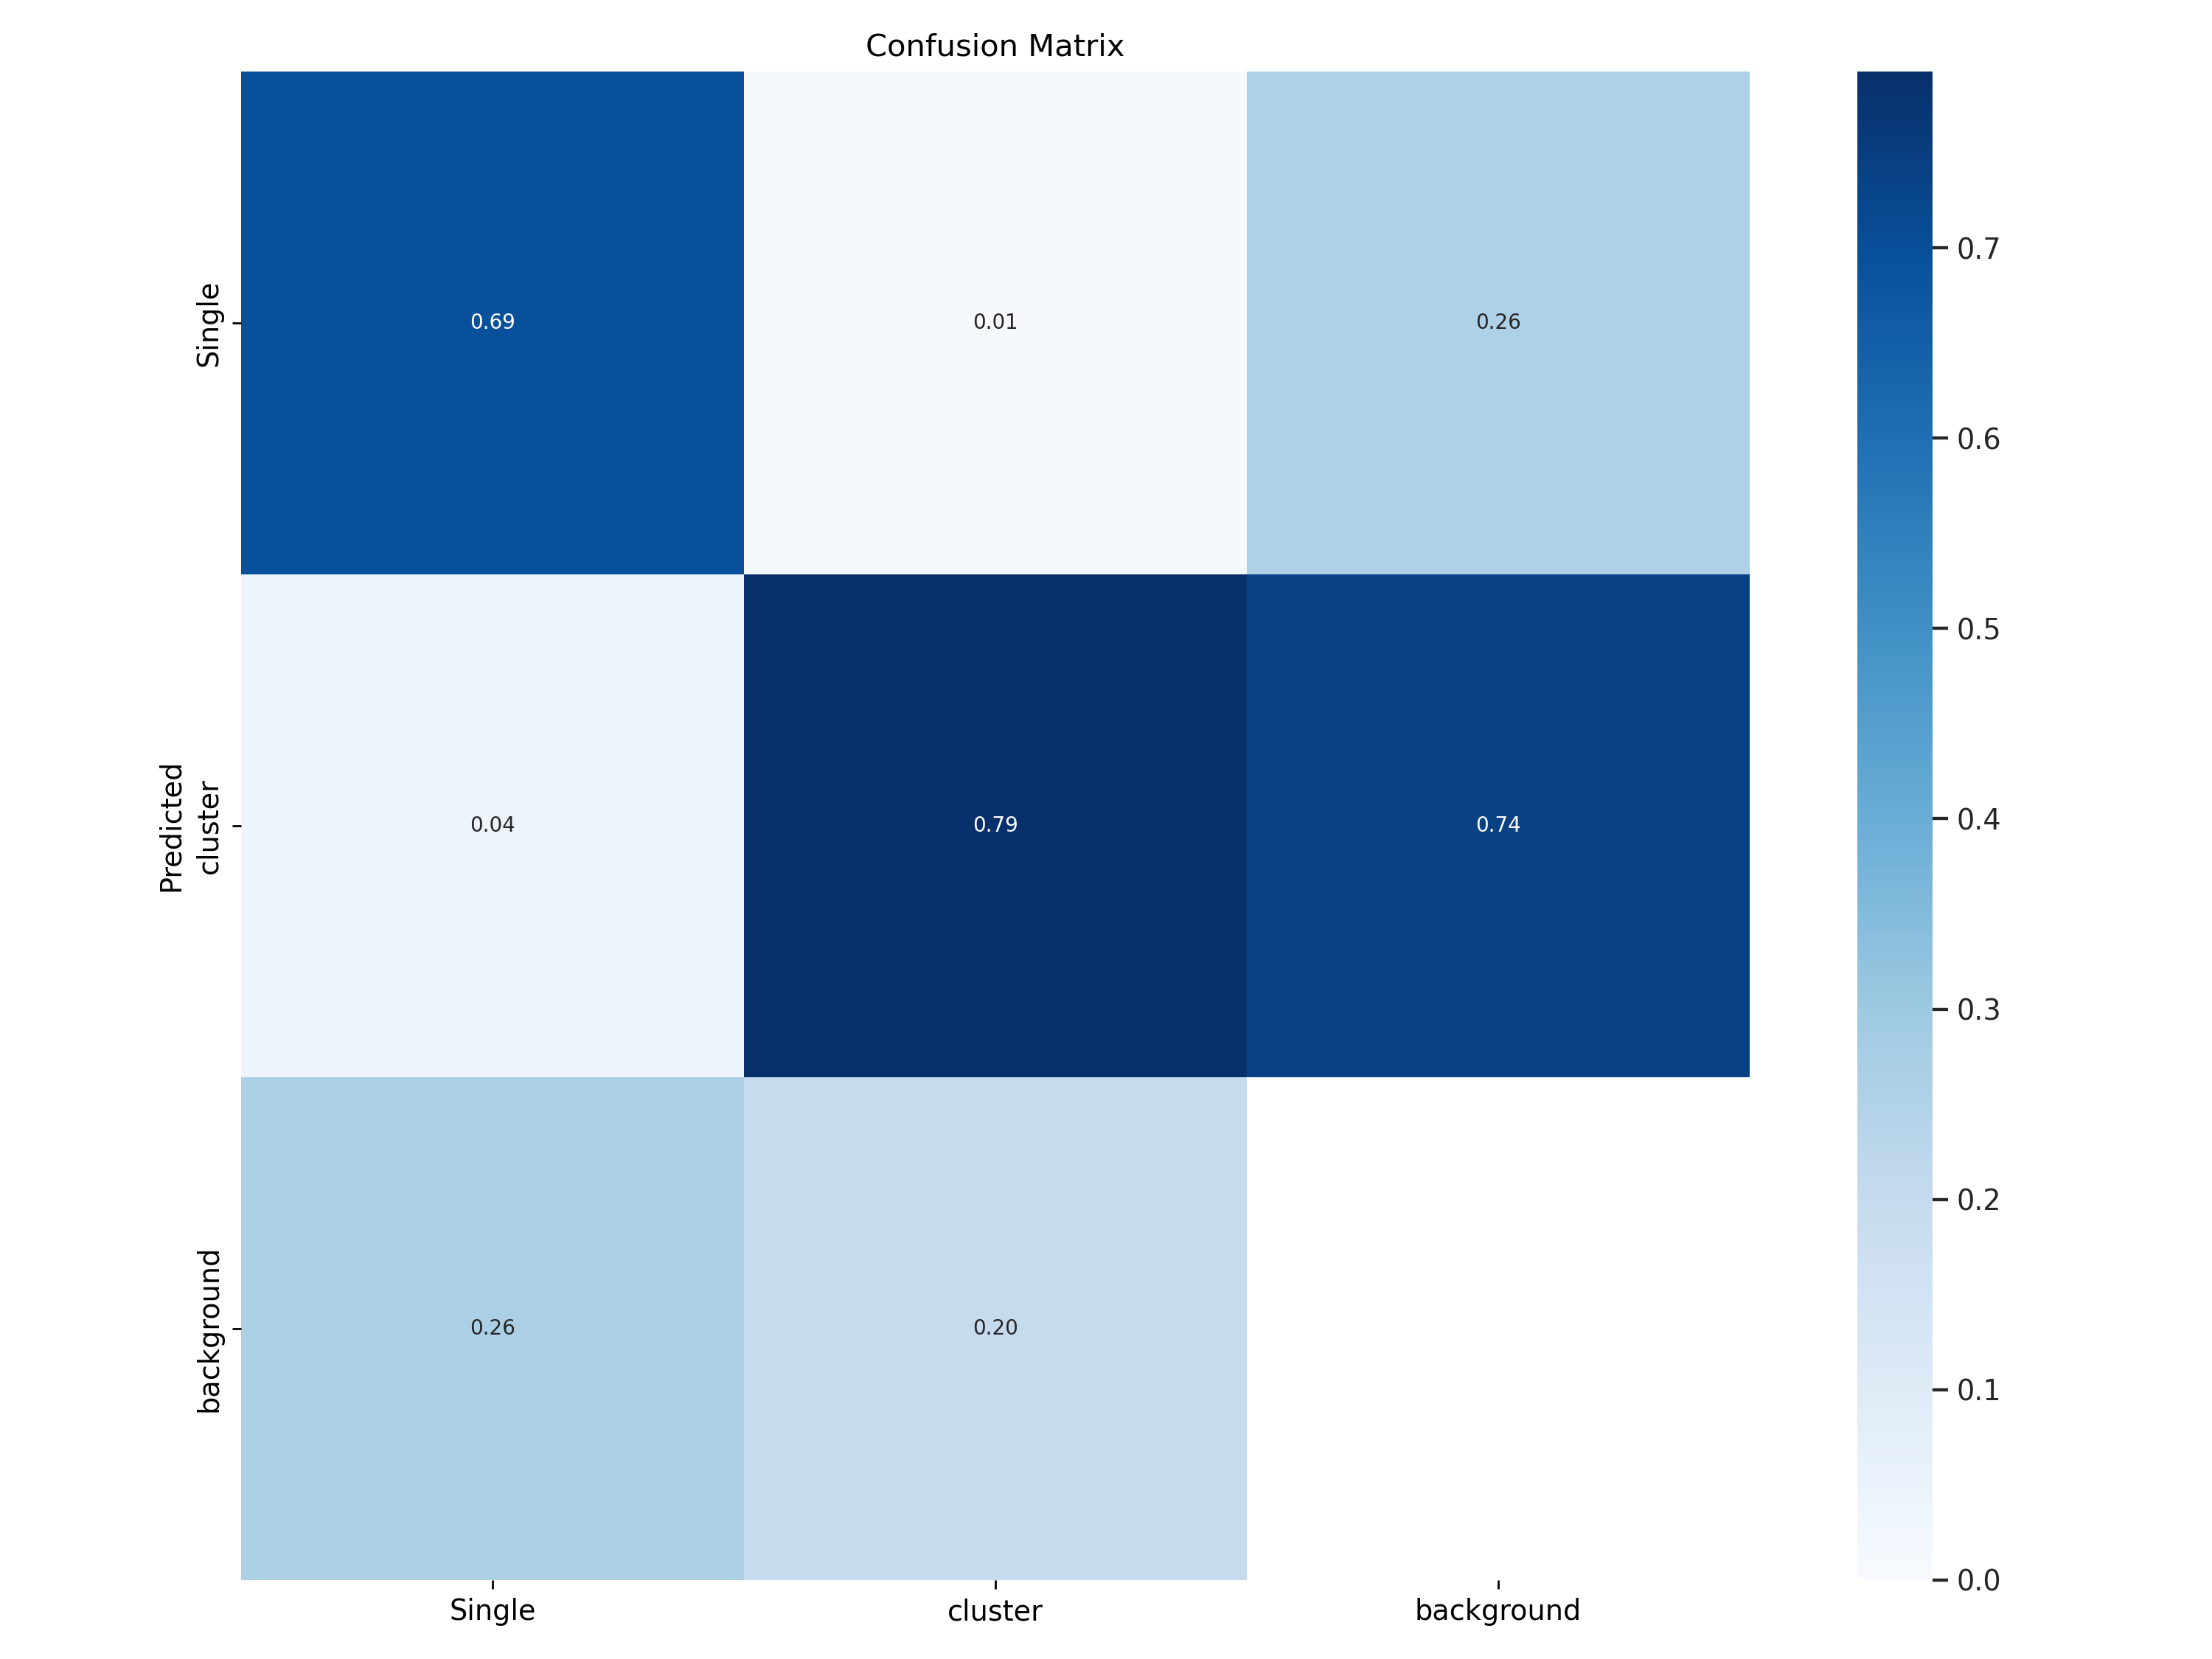

In [30]:
from IPython.display import Image

Image(filename=f"{HOME}/yolov9/runs/train/exp/confusion_matrix.png", width=1000)

In [32]:
from IPython.display import Image

Image(filename=f"{HOME}/yolov9/yolov9/runs/train/exp/val_batch0_pred.jpg", width=1000)

FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/workspace/solar-flare/yolov9/yolov9/runs/train/exp/val_batch0_pred.jpg'

In [34]:
%cd {HOME}/yolov9

!python val.py \
--img 640 --batch 32 --conf 0.001 --iou 0.7 --device 0 \
--data {dataset.location}/data.yaml \
--weights {HOME}/yolov9/runs/train/exp/weights/best.pt

/home/jovyan/workspace/solar-flare/yolov9
val: data=/home/jovyan/workspace/solar-flare/yolov9/sunspot-single-V-cluster-detection-9/data.yaml, weights=['/home/jovyan/workspace/solar-flare/yolov9/runs/train/exp/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.7, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False, min_items=0
YOLOv5 🚀 1e33dbb Python-3.10.13 torch-2.1.0 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
gelan-c summary: 467 layers, 25412502 parameters, 0 gradients, 102.5 GFLOPs
val: Scanning /home/jovyan/workspace/solar-flare/yolov9/sunspot-single-V-cluster
                 Class     Images  Instances          P          R      mAP50   Exception in thread Thread-3 (plot_images):
Traceback (most recent call last):
  File "/opt/saturncloud/envs/saturn/lib/python3.10/threading.py",

In [35]:
!python detect.py \
--img 1280 --conf 0.1 --device 0 \
--weights {HOME}/yolov9/runs/train/exp/weights/best.pt \
--source {dataset.location}/test/images

detect: weights=['/home/jovyan/workspace/solar-flare/yolov9/runs/train/exp/weights/best.pt'], source=/home/jovyan/workspace/solar-flare/yolov9/sunspot-single-V-cluster-detection-9/test/images, data=data/coco128.yaml, imgsz=[1280, 1280], conf_thres=0.1, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 1e33dbb Python-3.10.13 torch-2.1.0 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
gelan-c summary: 467 layers, 25412502 parameters, 0 gradients, 102.5 GFLOPs
image 1/44 /home/jovyan/workspace/solar-flare/yolov9/sunspot-single-V-cluster-detection-9/test/images/20211020_004500_Ic_flat_1k-jpg_jpg.rf.71e3e5a1ad1a16e12bf44a66e30cde16.jpg: 1280x1280 1 Single, 103.1ms
image 2/44 /home/jovyan/workspace/sol

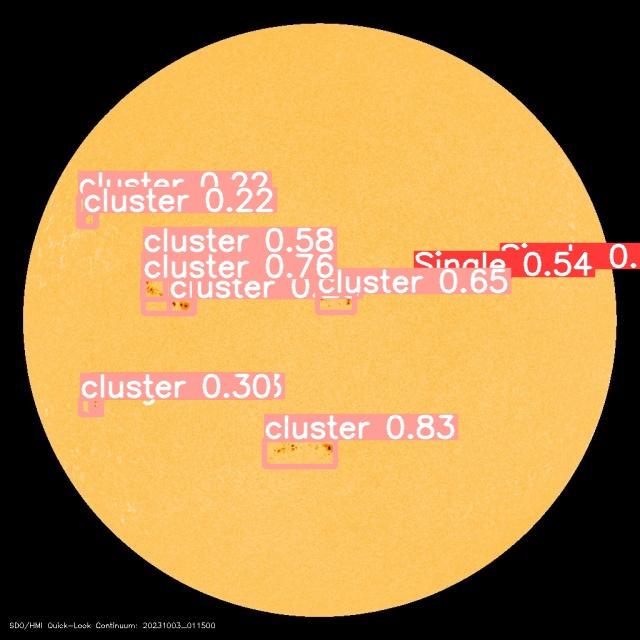

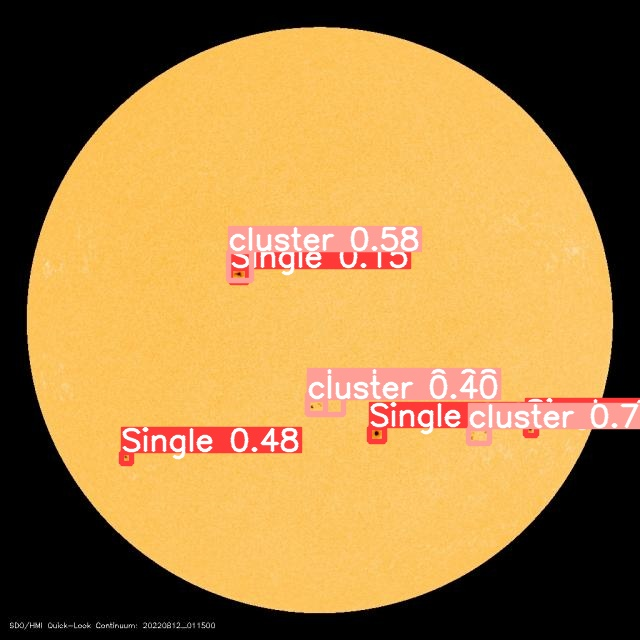

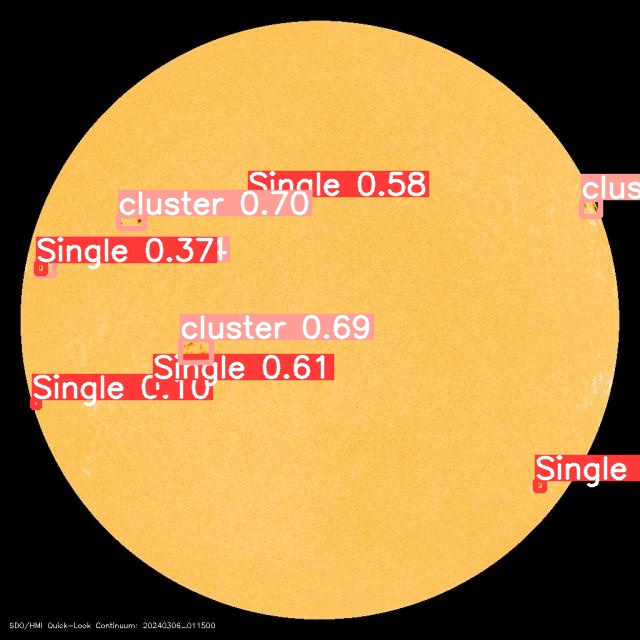

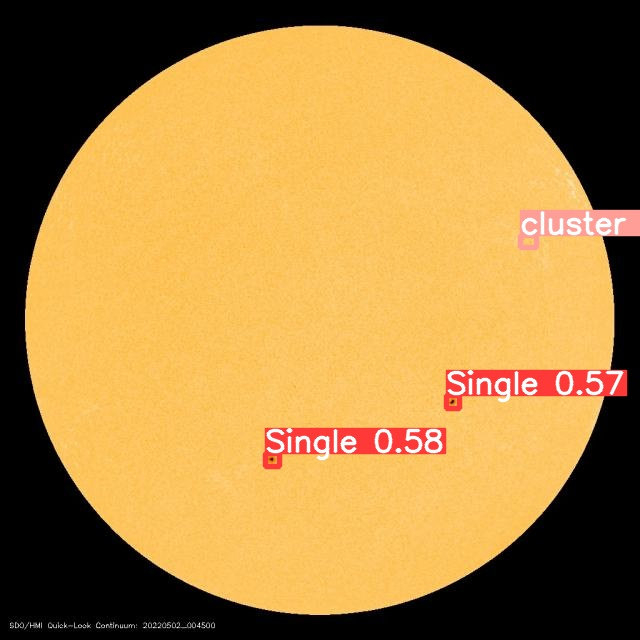

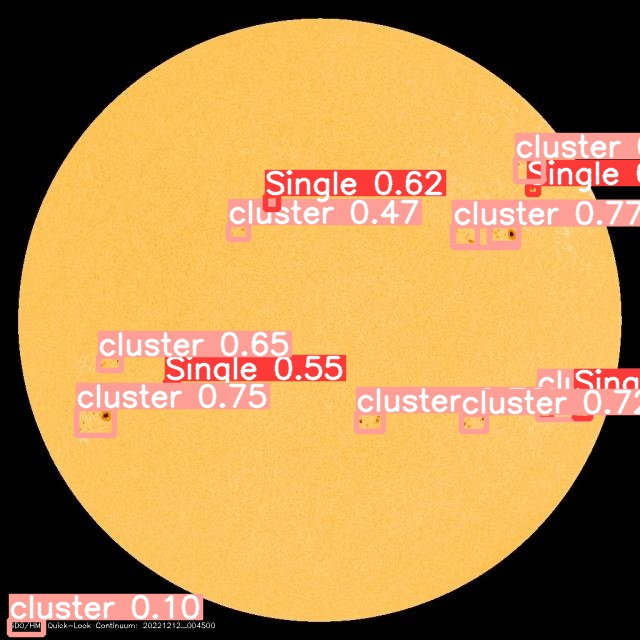

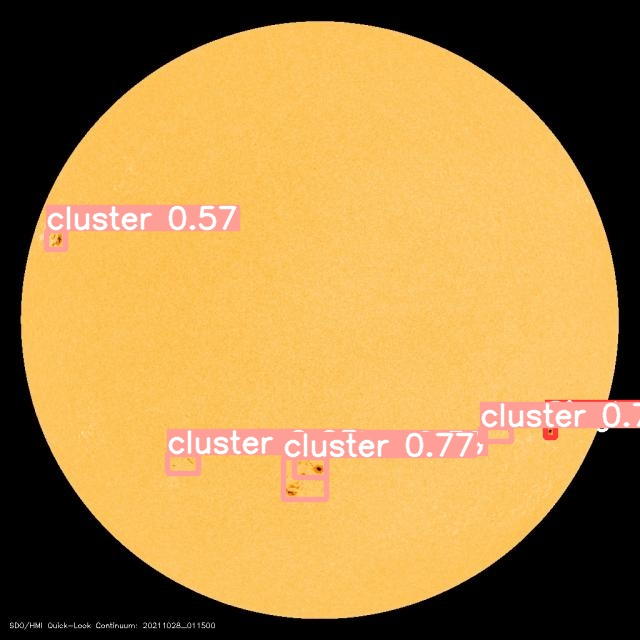

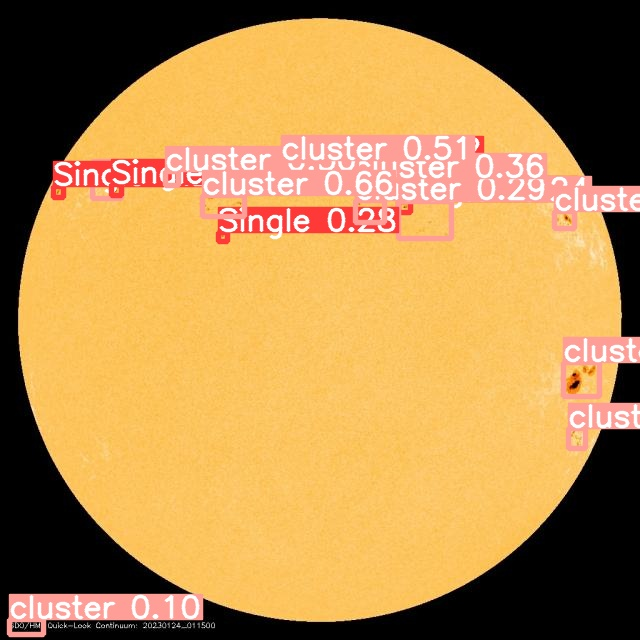

In [36]:
import glob

from IPython.display import Image, display

for image_path in glob.glob(f'{HOME}/yolov9/runs/detect/exp/*.jpg')[:7]:
      display(Image(filename=image_path, width=600))

In [37]:
!pip install -q inference supervision

ERROR: Cannot uninstall opencv-python 4.9.0, RECORD file not found. Hint: The package was installed by conda.


In [38]:
version.deploy(model_type="yolov9", model_path=f"{HOME}/yolov9/runs/train/exp")

View the status of your deployment at: https://app.roboflow.com/solarflarelabelling/sunspot-single-v-cluster-detection/9
Share your model with the world at: https://universe.roboflow.com/solarflarelabelling/sunspot-single-v-cluster-detection/model/9
